# 🚢 Titanic Survival Analysis - EDA Project

Welcome to my Exploratory Data Analysis (EDA) project on the Titanic dataset.  
This project investigates factors that influenced passenger survival in the Titanic disaster using data visualization and statistical techniques.

**Goal:** Identify key variables (like gender, age, class) that affected survival rate.


 **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


 **Load Data**

In [3]:
# Load the Titanic dataset (Make sure to upload the train.csv in Colab)
df = pd.read_csv('/content/train.csv')

# Display the first 5 rows
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 📊 Dataset Overview

- The dataset contains details of 891 passengers.
- Key features: `Age`, `Sex`, `Pclass`, `Fare`, `Embarked`, `Survived`, etc.
- `Survived` is the target variable (0 = No, 1 = Yes).


**Basic Data Exploration**

In [4]:
# Get basic information about the dataset
print(f"Data shape: {df.shape}")  # (rows, columns)
print("\nInfo about dataset (data types and non-null counts):")
df.info()

# Get summary statistics for numerical columns
print("\nSummary Statistics:")
df.describe()


Data shape: (891, 12)

Info about dataset (data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Summary Statistics:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Check for Missing Values**

In [5]:
# Check for missing values
print("\nMissing Values (Count):")
print(df.isnull().sum())



Missing Values (Count):
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**Data Cleaning**

In [6]:
# Fill missing 'Age' with median value
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing 'Embarked' with mode value
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop 'Cabin' column as it has too many missing values
df.drop(columns=['Cabin'], inplace=True)

# Check missing values after cleaning
print("\nMissing Values after cleaning:")
print(df.isnull().sum())



Missing Values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


<ipython-input-6-ca916180f58e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
<ipython-input-6-ca916180f58e>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

## 🧹 Data Cleaning

- `Age`: Filled missing values with median.
- `Embarked`: Filled with mode.
- `Cabin`: Dropped due to high missing values.
- Removed irrelevant features like `Ticket`, `Cabin`, and `Name` for EDA.


**Univariate Analysis (Individual Features)**

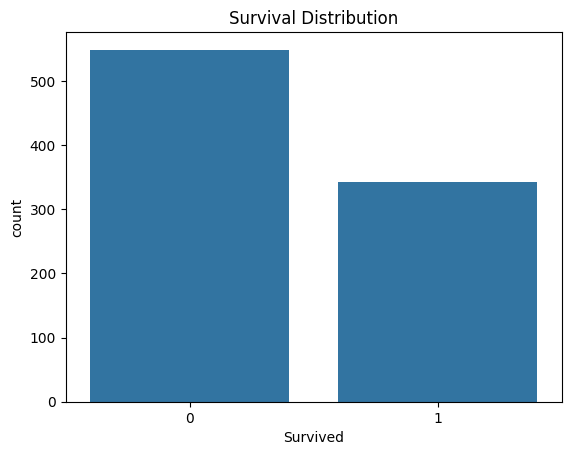

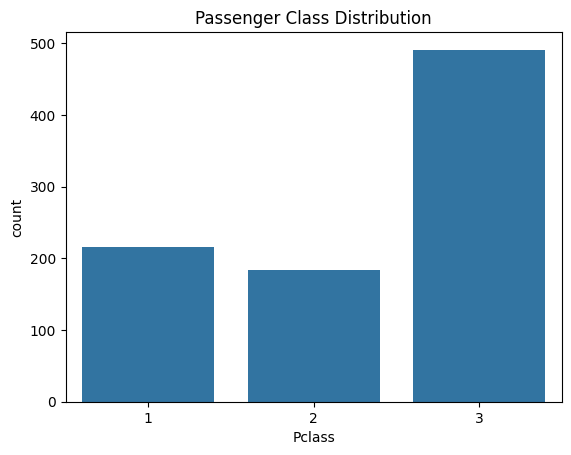

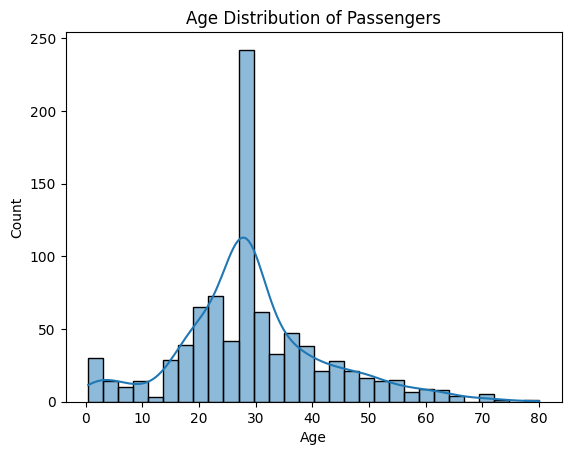

In [7]:
# Plot survival distribution
sns.countplot(x='Survived', data=df)
plt.title('Survival Distribution')
plt.show()

# Plot passenger class distribution
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.show()

# Plot age distribution
sns.histplot(df['Age'], kde=True, bins=30)
plt.title('Age Distribution of Passengers')
plt.show()


**Bivariate Analysis (Relationships Between Features)**

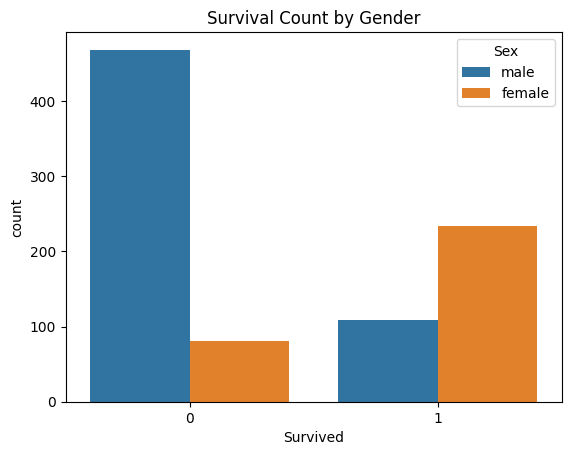

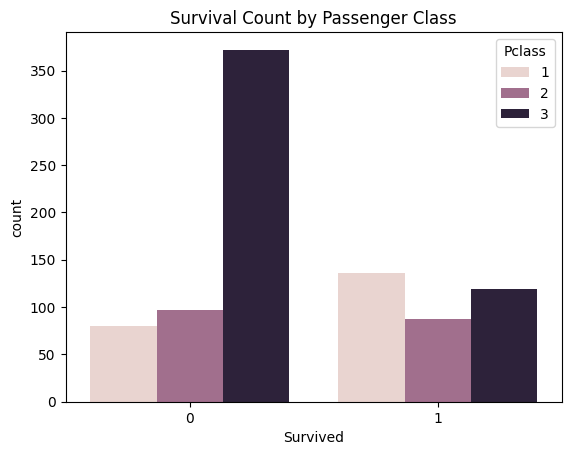

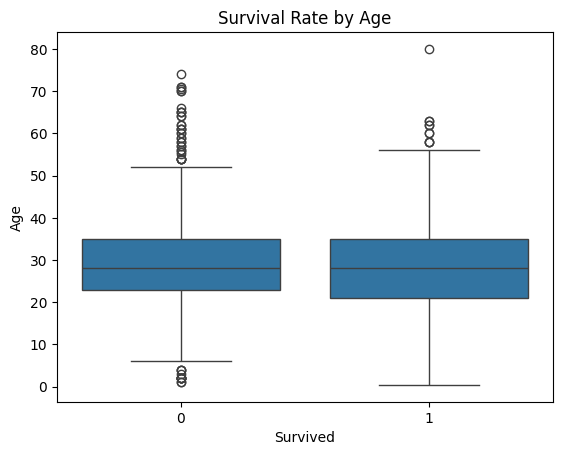

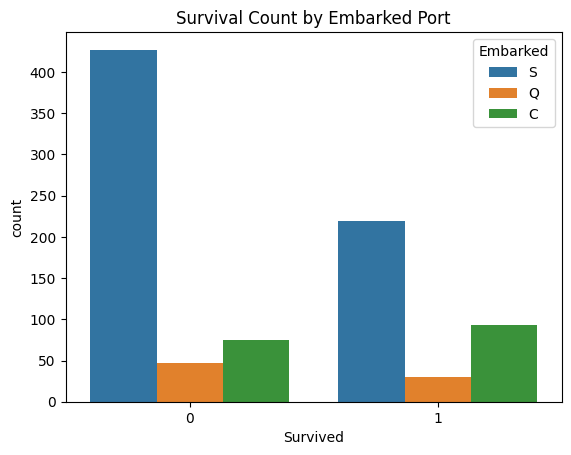

In [8]:
# Survival rate by Gender
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival Count by Gender')
plt.show()

# Survival rate by Passenger Class
sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival Count by Passenger Class')
plt.show()

# Survival rate by Age
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Survival Rate by Age')
plt.show()

# Survival rate by Embarked Port
sns.countplot(x='Survived', hue='Embarked', data=df)
plt.title('Survival Count by Embarked Port')
plt.show()


## 📈 Key Exploratory Findings

- **Gender**: Females had a much higher survival rate.
- **Class**: Passengers in 1st class had the highest survival.
- **Age**: Younger passengers (especially children) had higher survival.
- **Embarked**: Those who boarded at Cherbourg had better chances.


## 🔗 Correlation Analysis

- Strong negative correlation between `Sex` (male=1) and survival.
- Positive correlation between `Fare` and survival.
- Class (`Pclass`) and survival have negative correlation (higher class = more likely to survive).


**Correlation Analysis**

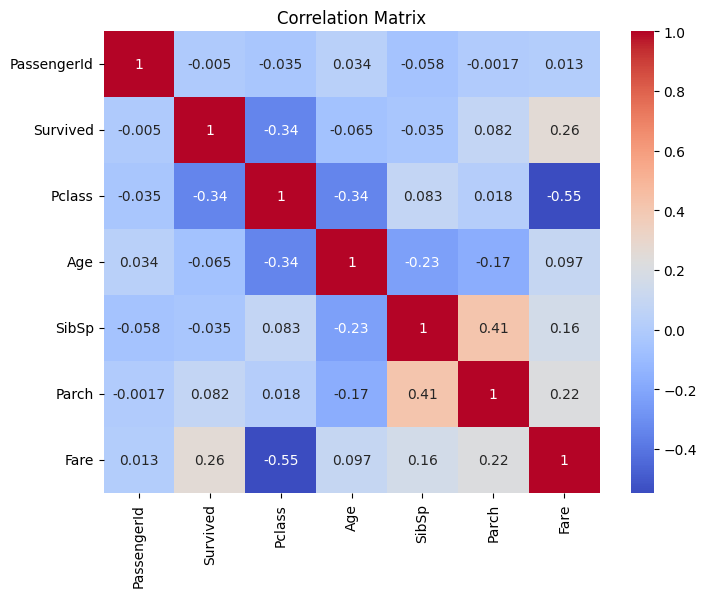

In [11]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


## ✅ Conclusion

- Women, children, and higher-class passengers had better survival chances.
- Visual EDA helped discover clear trends in survival probability.
- This EDA lays a solid foundation for building ML models in the next step.

Thanks for reading!
